In [4]:
print("SafePath AI setup compllete")

SafePath AI setup compllete


In [6]:
import pandas as pd

df = pd.read_csv("../data/CrimesOnWomenData.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 736
Columns: 10


,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [7]:
df.shape

(736, 10)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  736 non-null    int64
 1   State       736 non-null    str  
 2   Year        736 non-null    int64
 3   Rape        736 non-null    int64
 4   K&A         736 non-null    int64
 5   DD          736 non-null    int64
 6   AoW         736 non-null    int64
 7   AoM         736 non-null    int64
 8   DV          736 non-null    int64
 9   WT          736 non-null    int64
dtypes: int64(9), str(1)
memory usage: 64.5 KB


In [9]:
df.isnull().sum()

Unnamed: 0    0
State         0
Year          0
Rape          0
K&A           0
DD            0
AoW           0
AoM           0
DV            0
WT            0
dtype: int64

In [10]:
sorted(df["State"].unique())


['A & N ISLANDS',
 'A & N Islands',
 'ANDHRA PRADESH',
 'ARUNACHAL PRADESH',
 'ASSAM',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'BIHAR',
 'Bihar',
 'CHANDIGARH',
 'CHHATTISGARH',
 'Chandigarh',
 'Chhattisgarh',
 'D & N HAVELI',
 'D&N Haveli',
 'DAMAN & DIU',
 'Daman & Diu',
 'Delhi UT',
 'GOA',
 'GUJARAT',
 'Goa',
 'Gujarat',
 'HARYANA',
 'HIMACHAL PRADESH',
 'Haryana',
 'Himachal Pradesh',
 'JAMMU & KASHMIR',
 'JHARKHAND',
 'Jammu & Kashmir',
 'Jharkhand',
 'KARNATAKA',
 'KERALA',
 'Karnataka',
 'Kerala',
 'LAKSHADWEEP',
 'Lakshadweep',
 'MADHYA PRADESH',
 'MAHARASHTRA',
 'MANIPUR',
 'MEGHALAYA',
 'MIZORAM',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'NAGALAND',
 'Nagaland',
 'ODISHA',
 'Odisha',
 'PUDUCHERRY',
 'PUNJAB',
 'Puducherry',
 'Punjab',
 'RAJASTHAN',
 'Rajasthan',
 'SIKKIM',
 'Sikkim',
 'TAMIL NADU',
 'TRIPURA',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'UTTAR PRADESH',
 'UTTARAKHAND',
 'Uttar Pradesh',
 'Uttarakhand',
 'WEST BENGAL

In [11]:
df["State"] = df["State"].str.upper()

df["State"].nunique()

37

# Data Cleaning

## Cleaning Tasks Performed

1. Standardized State Names
2. Removed Duplicate State Naming Variations
3. Verified Missing Values

In [12]:
#Remove Useless Column
df = df.drop("Unnamed: 0", axis=1)

df.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,ASSAM,2001,817,1070,59,850,4,1248,0
3,BIHAR,2001,888,518,859,562,21,1558,83
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [13]:
#verify columns
df.columns

Index(['State', 'Year', 'Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV', 'WT'], dtype='str')

In [14]:
df.describe()

,Year,Rape,K&A,DD,AoW,AoM,DV,WT
count,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000
mean,2011.149457,727.855978,1134.542120,215.692935,1579.115489,332.722826,2595.078804,28.744565
std,6.053453,977.024945,1993.536828,424.927334,2463.962518,806.024551,4042.004953,79.999660
min,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,35.000000,24.750000,1.000000,34.000000,3.000000,13.000000,0.000000
50%,2011.000000,348.500000,290.000000,29.000000,387.500000,31.000000,678.500000,0.000000
75%,2016.000000,1069.000000,1216.000000,259.000000,2122.250000,277.500000,3545.000000,15.000000
max,2021.000000,6337.000000,15381.000000,2524.000000,14853.000000,9422.000000,23278.000000,549.000000


# Feature Engineering

Goal:
Create a Women Safety Index (WSI) using normalized crime indicators.

In [15]:
# MLand DATA SCIENCE concepts
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

crime_columns = ["Rape", "K&A", "DD", "AoW", "AoM", "DV", "WT"]

df_scaled = df.copy()

df_scaled[crime_columns] = scaler.fit_transform(df[crime_columns])

df_scaled.head()


,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,ANDHRA PRADESH,2001,0.137447,0.049737,0.166403,0.238605,0.241032,0.248776,0.012750
1,ARUNACHAL PRADESH,2001,0.005208,0.003576,0.000000,0.005251,0.000318,0.000473,0.000000
2,ASSAM,2001,0.128925,0.069566,0.023376,0.057227,0.000425,0.053613,0.000000
3,BIHAR,2001,0.140129,0.033678,0.340333,0.037837,0.002229,0.066930,0.151184
4,CHHATTISGARH,2001,0.151333,0.011118,0.027734,0.118697,0.017088,0.036086,0.000000


In [16]:
df_scaled[crime_columns].describe()

,Rape,K&A,DD,AoW,AoM,DV,WT
count,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000
mean,0.114858,0.073763,0.085457,0.106316,0.035313,0.111482,0.052358
std,0.154178,0.129610,0.168355,0.165890,0.085547,0.173641,0.145719
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.005523,0.001609,0.000396,0.002289,0.000318,0.000558,0.000000
50%,0.054994,0.018854,0.011490,0.026089,0.003290,0.029148,0.000000
75%,0.168692,0.079059,0.102615,0.142884,0.029452,0.152290,0.027322
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
#EDA
state_crime = df.groupby("State")[["Rape","K&A","DD","AoW","DV","WT"]].sum()

state_crime["Total_Crime"] = state_crime.sum(axis=1)

state_crime = state_crime.sort_values("Total_Crime", ascending=False)

state_crime.head(10)

,Rape,K&A,DD,AoW,DV,WT,Total_Crime
State,,,,,,,
UTTAR PRADESH,45694,133856,40615,99650,163062,333,483210
WEST BENGAL,29486,51742,8075,51014,262235,940,403492
MADHYA PRADESH,72808,57485,13316,152000,95521,396,391526
RAJASTHAN,43799,55320,7769,67855,201488,668,376899
ANDHRA PRADESH,23424,21707,8165,92084,188511,2548,336439
MAHARASHTRA,39252,46522,5756,107519,133357,2533,334939
ASSAM,32190,71462,2757,47115,135415,343,289282
KERALA,24184,14056,1525,69081,84277,990,194113
BIHAR,21006,77687,24428,9953,55187,825,189086


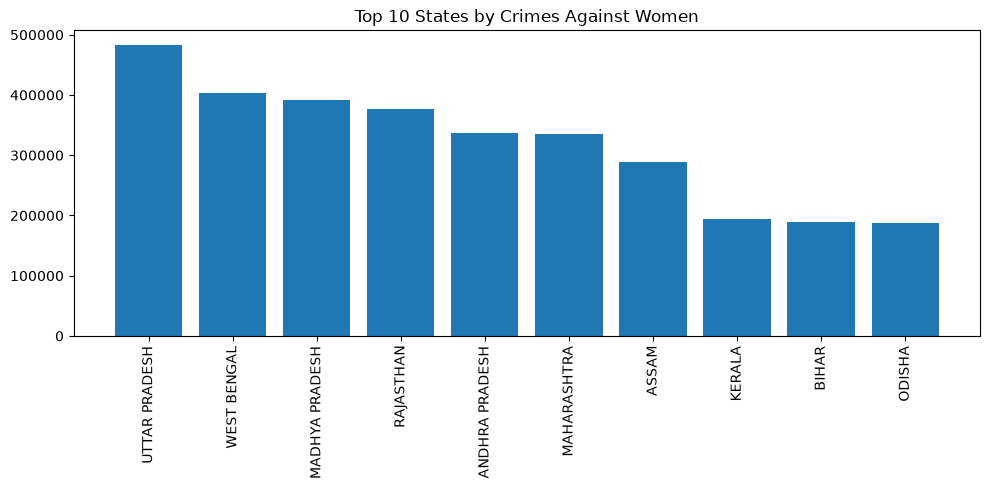

In [18]:
#plotting the state_crime
import matplotlib.pyplot as plt

top10 = state_crime.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10["Total_Crime"])
plt.xticks(rotation=90)
plt.title("Top 10 States by Crimes Against Women")
plt.tight_layout()
plt.show()

In [19]:
#Crime Trend Analysis
yearly_crime = df.groupby("Year")[["Rape","K&A","DD","AoW","DV","WT"]].sum()

yearly_crime["Total_Crime"] = yearly_crime.sum(axis=1)

yearly_crime.head()

,Rape,K&A,DD,AoW,DV,WT,Total_Crime
Year,,,,,,,
2001,15694,13681,6738,33622,49032,114,118881
2002,15970,13613,6687,33497,49102,76,118945
2003,15357,12499,6078,32450,49492,46,115922
2004,17682,14697,6900,33966,56867,89,130201
2005,17701,14644,6673,33413,56995,148,129574


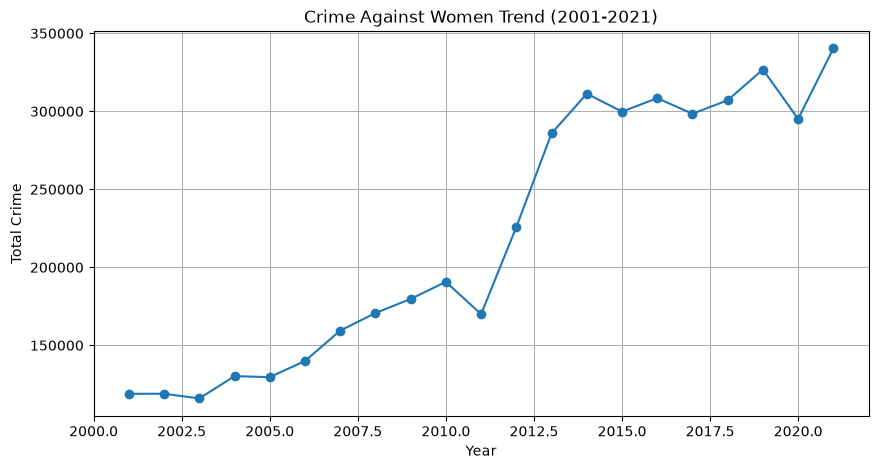

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    yearly_crime.index,
    yearly_crime["Total_Crime"],
    marker="o"
)

plt.title("Crime Against Women Trend (2001-2021)")
plt.xlabel("Year")
plt.ylabel("Total Crime")

plt.grid(True)

plt.show()

In [21]:
#analyzing the dominant crime
crime_totals = df[["Rape","K&A","DD","AoW","AoM","DV","WT"]].sum()

crime_totals.sort_values(ascending=False)

DV      1909978
AoW     1162229
K&A      835023
Rape     535702
AoM      244884
DD       158750
WT        21156
dtype: int64

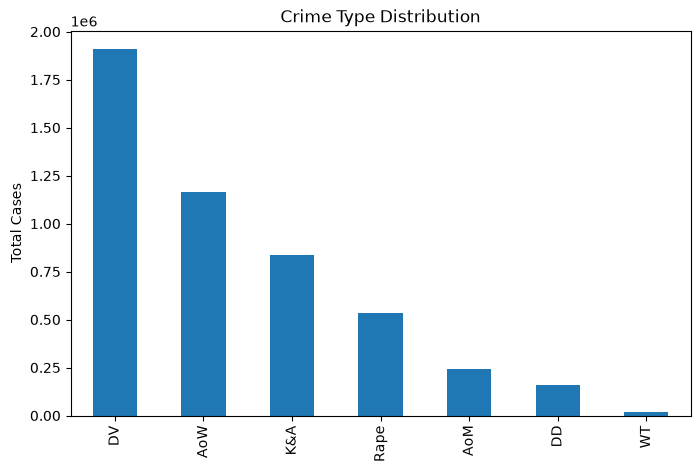

In [22]:
#plotting
import matplotlib.pyplot as plt

crime_totals.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Crime Type Distribution")
plt.ylabel("Total Cases")
plt.show()

In [23]:
#Crime risk score evaluation
df_scaled["Crime_Risk_Score"] = (
    df_scaled["Rape"] * 0.30 +
    df_scaled["K&A"] * 0.25 +
    df_scaled["AoW"] * 0.20 +
    df_scaled["DV"] * 0.15 +
    df_scaled["DD"] * 0.05 +
    df_scaled["WT"] * 0.05
)

df_scaled[["State", "Year", "Crime_Risk_Score"]].head()

,State,Year,Crime_Risk_Score
0,ANDHRA PRADESH,2001,0.147663
1,ARUNACHAL PRADESH,2001,0.003577
2,ASSAM,2001,0.076725
3,BIHAR,2001,0.092641
4,CHHATTISGARH,2001,0.078718


In [24]:
df_scaled["Crime_Risk_Score"].describe()

count    736.000000
mean       0.097774
std        0.129451
min        0.000000
25%        0.003069
50%        0.049906
75%        0.155774
max        0.748454
Name: Crime_Risk_Score, dtype: float64

WSI evaluation

In [25]:
df_scaled["Women_Safety_Index"] = (
    100 - (df_scaled["Crime_Risk_Score"] * 100)
)

df_scaled[["State","Year","Women_Safety_Index"]].head()

,State,Year,Women_Safety_Index
0,ANDHRA PRADESH,2001,85.233681
1,ARUNACHAL PRADESH,2001,99.642261
2,ASSAM,2001,92.327460
3,BIHAR,2001,90.735885
4,CHHATTISGARH,2001,92.128173


In [26]:
df_scaled["Women_Safety_Index"].describe()

count    736.000000
mean      90.222562
std       12.945138
min       25.154602
25%       84.422613
50%       95.009389
75%       99.693073
max      100.000000
Name: Women_Safety_Index, dtype: float64

Top 10 safest states

In [27]:
state_wsi = (
    df_scaled.groupby("State")["Women_Safety_Index"]
    .mean()
    .sort_values(ascending=False)
)

state_wsi.head(10)


State
LAKSHADWEEP          99.993418
D & N HAVELI         99.955640
PUDUCHERRY           99.881469
A & N ISLANDS        99.823778
MIZORAM              99.626330
CHANDIGARH           99.578596
MANIPUR              99.562306
GOA                  99.558745
ARUNACHAL PRADESH    99.515011
DAMAN & DIU          99.450025
Name: Women_Safety_Index, dtype: float64

Top 10 riskiest states 

In [28]:
state_wsi.tail(10)

State
DELHI UT          84.698887
ODISHA            84.653071
BIHAR             84.257887
ASSAM             79.627126
ANDHRA PRADESH    79.475151
WEST BENGAL       76.860957
MAHARASHTRA       74.922786
RAJASTHAN         74.288394
MADHYA PRADESH    65.032113
UTTAR PRADESH     63.969812
Name: Women_Safety_Index, dtype: float64

WSI rankings were cross-validated against EDA findings. States identified as high-crime regions during exploratory analysis also appeared among the lowest-ranked regions in the Women Safety Index, increasing confidence in the scoring framework

In [29]:
df["State"] = df["State"].str.strip()

print("Unique States:", df["State"].nunique())
print(sorted(df["State"].unique()))

Unique States: 37
['A & N ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'D & N HAVELI', 'D&N HAVELI', 'DAMAN & DIU', 'DELHI UT', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']
